# Mini-Projeto: Modelagem e Solução de Problemas com Aprendizado por Reforço

**Alunos:** [Insira o nome dos integrantes do grupo aqui]

Neste notebook, vocês irão desenvolver o projeto prático da disciplina. O objetivo é aplicar os algoritmos tabulares clássicos em um ambiente de espaço contínuo (`MountainCar-v0`), utilizando técnicas de discretização, conforme o enunciado.

Deixe, neste colab, somente o código necessário para treinar os agentes com a parametrização mais vantajosa e gerar os gráficos, além do relatório em texto, na **análise dos resultados** e no **diário de bordo**. O restante da experimentação pode ser feito em outros colabs e ambientes. O diário de bordo deve comentar essa jornada e pode referenciar esses outros artefatos.

## Tarefa A: Modelagem do Espaço de Estados (Discretização)

Implementem abaixo **duas formas ou resoluções de discretização diferentes**

In [1]:
# ==============================================================================
# TAREFA A: FUNÇÕES DE DISCRETIZAÇÃO
# ==============================================================================

import gymnasium as gym
from modules.discretization import StateDiscretizer, get_coarse_discretizer, get_fine_discretizer

# Criando ambiente base para obtenção dos limites do espaço de observação
env = gym.make("MountainCar-v0")

# Discretização 1: Grossa (Coarse - 10x10 bins = 100 estados discretos)
discretizer_coarse = get_coarse_discretizer(env)

# Discretização 2: Fina (Fine - 40x40 bins = 1600 estados discretos)
discretizer_fine = get_fine_discretizer(env)

## Tarefa B: Implementação dos Agentes Tabulares
Implementem os algoritmos solicitados.

In [2]:
# ==============================================================================
# TAREFA B: AGENTES
# ==============================================================================

from modules.agents import BaseAgent, QLearningAgent, SarsaLambdaAgent, DynaQAgent

# Os agentes tabulares (Baseline / Q-Learning, SARSA(λ) e Dyna-Q) estão implementados
# no módulo `modules.agents` importado acima.

## Tarefa C: Avaliação Experimental e Reprodutibilidade
Treine cada algoritmo pelo menos 10 vezes com sementes diferentes (seeds) para lidar com a alta variância do Aprendizado por Reforço.

In [3]:
# ==============================================================================
# TAREFA C: Execução dos experimentos para ambas as representações
# ==============================================================================

import pandas as pd
from modules.experiments import run_experiment

# Configuração de 10 sementes fixas para reprodutibilidade
seeds = [10, 22, 33, 44, 55, 66, 77, 88, 99, 100]
episodes = 500

# ------------------------------------------------------------------------------
# 1. Experimentos na Discretização Grossa (10x10 bins)
# ------------------------------------------------------------------------------
print("--- Rodando experimentos na Discretização Grossa (10x10) ---")
df_q_coarse = run_experiment(QLearningAgent, discretizer_coarse, episodes=episodes, seeds=seeds, representation_name="Grossa (10x10)")
df_sarsa_coarse = run_experiment(SarsaLambdaAgent, discretizer_coarse, episodes=episodes, seeds=seeds, lambd=0.9, representation_name="Grossa (10x10)")
df_dyna_coarse = run_experiment(DynaQAgent, discretizer_coarse, episodes=episodes, seeds=seeds, n_planning_steps=10, representation_name="Grossa (10x10)")

# ------------------------------------------------------------------------------
# 2. Experimentos na Discretização Fina (40x40 bins)
# ------------------------------------------------------------------------------
print("--- Rodando experimentos na Discretização Fina (40x40) ---")
df_q_fine = run_experiment(QLearningAgent, discretizer_fine, episodes=episodes, seeds=seeds, representation_name="Fina (40x40)")
df_sarsa_fine = run_experiment(SarsaLambdaAgent, discretizer_fine, episodes=episodes, seeds=seeds, lambd=0.9, representation_name="Fina (40x40)")
df_dyna_fine = run_experiment(DynaQAgent, discretizer_fine, episodes=episodes, seeds=seeds, n_planning_steps=10, representation_name="Fina (40x40)")

# Consolidação de todos os experimentos em um único DataFrame
df_all = pd.concat([df_q_coarse, df_sarsa_coarse, df_dyna_coarse, df_q_fine, df_sarsa_fine, df_dyna_fine], ignore_index=True)

--- Rodando experimentos na Discretização Grossa (10x10) ---


Treinando DynaQAgent [Grossa (10x10)]: 100%|██████████| 10/10 [00:39<00:00,  3.94s/it]


--- Rodando experimentos na Discretização Fina (40x40) ---


Treinando DynaQAgent [Fina (40x40)]: 100%|██████████| 10/10 [00:42<00:00,  4.26s/it]


## 4.1 Gráficos de Curva de Aprendizado

Com os dados coletados, gerem os dois conjuntos de gráficos exigidos. Utilizem o `seaborn.lineplot`, pois ele calcula e desenha o Intervalo de Confiança de 95% automaticamente ao receber dados de múltiplas repetições (seeds).

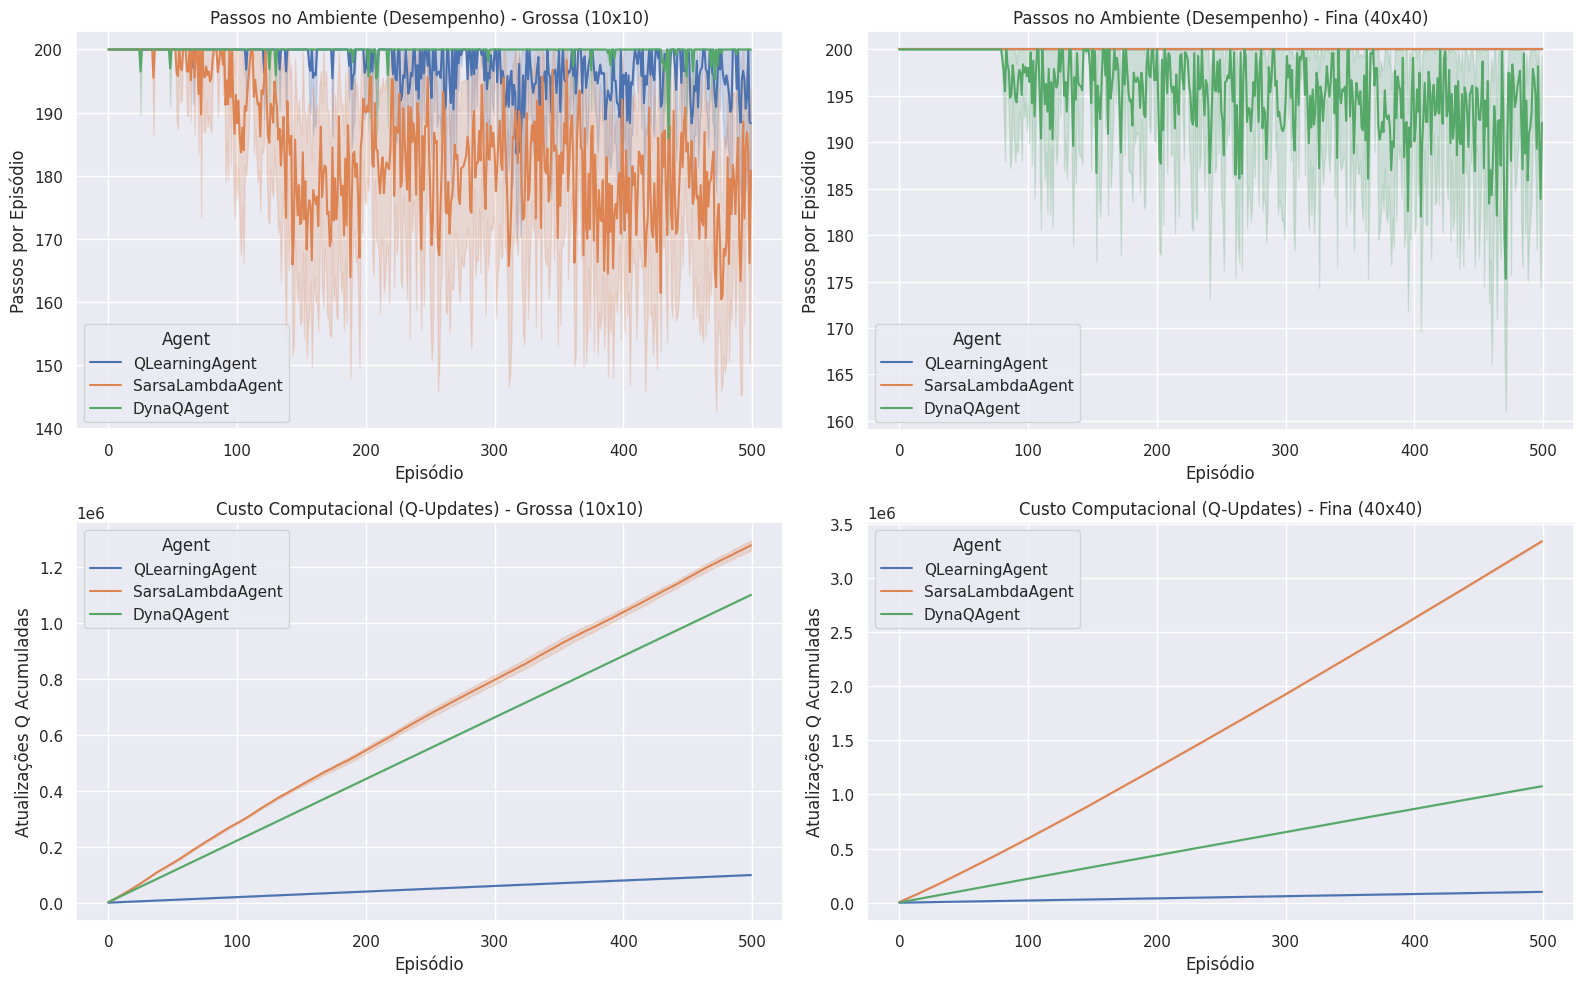

--- Tabela Estatística Resumo (Média e Desvio Padrão nos últimos episódios e Total de Q-Updates) ---


,Representation,Agent,Mean_Final_Steps,Std_Final_Steps,Mean_Total_Q_Updates,Std_Total_Q_Updates
0,Fina (40x40),DynaQAgent,191.901961,15.166340,1076291.7,3787.704114
1,Fina (40x40),QLearningAgent,200.000000,0.000000,100000.0,0.000000
2,Fina (40x40),SarsaLambdaAgent,200.000000,0.000000,3339898.4,11788.258190
3,Grossa (10x10),DynaQAgent,199.623529,3.632347,1099004.5,1286.224125
4,Grossa (10x10),QLearningAgent,195.262745,12.769284,98829.6,464.528243
5,Grossa (10x10),SarsaLambdaAgent,176.054902,26.383616,1275832.3,31062.675670


In [4]:
# ==============================================================================
# GRÁFICOS E DADOS DETALHADOS PARA TOMADA DE DECISÃO
# ==============================================================================

from modules.experiments import plot_learning_curves, summarize_experiments
from IPython.display import display

# 1. Geração dos gráficos comparativos com Intervalo de Confiança de 95% para ambas as representações
# Exibe um painel contendo:
# - Eixo x: Contagem de episódios
# - Eixo y (Desempenho): Número de passos até o sucesso (média + sombreamento IC 95%)
# - Eixo y (Custo): Número de atualizações de valor-Q acumuladas (média + sombreamento IC 95%)
plot_learning_curves(df_all)

# 2. Apresentação da Tabela Resumo com dados estatísticos agregados para tomada de decisão
print("--- Tabela Estatística Resumo (Média e Desvio Padrão nos últimos episódios e Total de Q-Updates) ---")
summary_table = summarize_experiments(df_all)
display(summary_table)

In [5]:
# ==============================================================================
# TAXA DE SUCESSO: EPISÓDIOS EM QUE O AGENTE CHEGOU À BANDEIRA (< 200 PASSOS)
# ==============================================================================
import pandas as pd
from IPython.display import display

linhas = []
for (rep, agente), g in df_all.groupby(["Representation", "Agent"]):
    chegou = g["Steps"] < 200
    por_seed = chegou.groupby(g["Seed"]).sum()
    primeiro = g.loc[chegou].groupby("Seed")["Episode"].min()
    ultimos = g["Episode"] >= g["Episode"].max() - 49
    linhas.append({
        "Representação": rep,
        "Agente": agente,
        "Seeds que chegaram": f"{int((por_seed > 0).sum())}/{g['Seed'].nunique()}",
        "Episódios com sucesso (%)": round(100 * chegou.mean(), 1),
        "Sucesso nos últimos 50 (%)": round(100 * chegou[ultimos].mean(), 1),
        "1º sucesso (episódio mín-máx)": f"{primeiro.min()}-{primeiro.max()}" if len(primeiro) else "-",
    })
display(pd.DataFrame(linhas))

,Representação,Agente,Seeds que chegaram,Episódios com sucesso (%),Sucesso nos últimos 50 (%),1º sucesso (episódio mín-máx)
0,Fina (40x40),DynaQAgent,10/10,18.4,29.8,80-96
1,Fina (40x40),QLearningAgent,0/10,0.0,0.0,-
2,Fina (40x40),SarsaLambdaAgent,0/10,0.0,0.0,-
3,Grossa (10x10),DynaQAgent,8/10,0.7,1.2,25-437
4,Grossa (10x10),QLearningAgent,10/10,7.2,14.4,66-239
5,Grossa (10x10),SarsaLambdaAgent,10/10,38.5,56.8,35-127


## 4.2 Análise de Resultados e Aliasing de Estados

*(Respondam de forma dissertativa, embasando-se nos gráficos gerados acima)*

**Como ler os resultados.** Todos os agentes foram treinados por 500 episódios, com 10 seeds, usando uma única parametrização (alpha = 0.1, gamma = 0.99, epsilon = 0.1 fixo, λ = 0.9, N = 10). As seeds do numpy, do ambiente e do módulo `random` são fixadas, então reexecutar o notebook (com as mesmas versões de bibliotecas) reproduz os mesmos números. O episódio é truncado em 200 passos, então "200 passos" significa que o agente não chegou à bandeira naquele episódio. Os números abaixo vêm da tabela resumo (média dos últimos ~50 episódios de treino), da tabela de taxa de sucesso, dos gráficos acima e da avaliação gulosa impressa na célula de vídeo.

**a) Qual o melhor algoritmo em termos de eficiência amostral?**
> O **SARSA(λ) com a discretização grossa (10x10)** é o mais eficiente em amostras. É o único que desce de forma consistente abaixo do teto de 200 passos: a curva laranja começa a cair entre os episódios 100 e 150 e termina com média de ~176 passos nos últimos episódios, contra ~195 do Q-Learning e ~200 do Dyna-Q na mesma discretização. Pela tabela de sucesso, ele chega à bandeira em 38,5% dos episódios (56,8% nos últimos 50), em todas as 10 seeds, com o primeiro sucesso entre os episódios 35 e 127; o Q-Learning chega em 7,2% dos episódios (primeiro sucesso entre os episódios 66 e 239) e o Dyna-Q em 0,7%. A explicação mais direta é o traço de elegibilidade. No MountainCar-v0 a única informação útil é chegar à bandeira (a recompensa é -1 em todos os passos), e o TD de 1 passo só leva essa informação um estado para trás a cada atualização, enquanto o traço distribui o sinal por toda a trajetória recente (decaimento γλ ≈ 0,89 por passo) já na primeira vez em que a bandeira é alcançada.
>
> O mesmo aparece na avaliação gulosa da célula de vídeo (agentes treinados com as mesmas 10 seeds, epsilon = 0, 20 largadas): o SARSA(λ) grosso chega à bandeira em 90% das largadas no melhor caso e em pelo menos 45% das largadas em 6 das 10 seeds (duas seeds ficam em 0%), enquanto o Dyna-Q grosso chega em 5% no melhor caso e em 0% nas outras 9 seeds.
>
> Na discretização fina o quadro se inverte: Q-Learning e SARSA(λ) ficam cravados em 200 passos (nenhum episódio com sucesso em nenhuma seed), e quem se destaca é o **Dyna-Q** (~192 passos; chega à bandeira em 18,4% dos episódios, em todas as 10 seeds, com o primeiro sucesso entre os episódios 80 e 96). Ou seja, o melhor algoritmo em eficiência amostral depende da discretização, o que é discutido em (c).

**b) Qual o melhor algoritmo em termos de eficiência computacional?**
> O **Q-Learning**. Ele faz exatamente uma atualização de valor Q por passo (≈100 mil em 500 episódios de 200 passos) e foi também o mais rápido em tempo de relógio (~17 s para as 10 seeds, nas duas discretizações, nesta execução). O SARSA(λ) vem em seguida em tempo (~20 s na grossa e ~31 s na fina), mas faz mais atualizações: a cada passo ele atualiza todos os pares (s, a) com traço ativo, e nesta implementação traços abaixo de 1e-3 (cerca de 60 passos de memória com γλ ≈ 0,89) são descartados. Isso dá ≈1,28 milhão de atualizações na grossa (~13x o Q-Learning) e ≈3,34 milhões na fina (~33x); na grossa o carro passa vários passos na mesma célula, então provavelmente há menos pares distintos com traço ativo do que na fina. O Dyna-Q faz N + 1 = 11 atualizações por passo por construção (≈1,1 milhão nas duas discretizações, ~11x o Q-Learning) e foi o mais lento (~39 s na grossa e ~42 s na fina), mesmo com menos atualizações que o SARSA(λ) nas duas discretizações. Isso sugere que cada atualização de planejamento é mais cara (sorteio no modelo e busca do melhor valor em Q), embora não tenhamos feito profiling.
>
> Em resumo: o Q-Learning é o mais barato nas duas medidas (atualizações e tempo). O SARSA(λ) paga um custo extra moderado e é o único que, na grossa, recebe de volta uma melhora clara de desempenho. O Dyna-Q é o mais caro em tempo e só compensa na discretização fina.

**c) Como a modelagem de estados afetou especificamente o modelo construído pelo Dyna-Q em comparação com o SARSA(λ)? Pense na relação entre as transições reais do ambiente vs nos estados discretizados.**
> Cada estado discreto agrupa muitos estados contínuos (posição, velocidade) diferentes, o que gera **aliasing**: o mesmo par (s, a) pode levar a estados discretos distintos dependendo de onde exatamente o carro estava dentro da célula. O Dyna-Q guarda um modelo **determinístico**, (s, a) → (r, s', done), com o último desfecho observado, e o planejamento reaplica essa transição como se fosse certa.
>
> Com a discretização **grossa** isso é especialmente prejudicial. Cada bin de posição cobre ~0,2 e cada bin de velocidade ~0,016, enquanto a velocidade do carro muda no máximo ~0,0035 por passo. Na maior parte dos passos o próximo estado discreto é a própria célula (auto-transição) e só de vez em quando é a vizinha, dependendo da posição exata dentro da célula. O modelo acaba guardando uma "foto" arbitrária de um desfecho que, do ponto de vista do estado discreto, é estocástico, e as 10 atualizações de planejamento por passo reforçam esse desfecho repetidamente, enviesando Q. Isso é compatível com o que observamos: na grossa o Dyna-Q fica praticamente em 200 passos (~199,6), pior que o Q-Learning (~195,3) mesmo fazendo ~11x mais atualizações. Na avaliação gulosa da célula de vídeo, o Dyna-Q grosso chegou à bandeira em 5% das largadas numa seed e em 0% nas outras nove. Com a discretização **fina** as células são pequenas (~0,046 em posição e ~0,0036 em velocidade), a transição observada se aproxima muito mais da dinâmica real, o modelo fica mais fiel e o planejamento passa a ajudar: o Dyna-Q cai para ~192 passos e é o único dos três que aprende nessa discretização.
>
> O **SARSA(λ)** não constrói modelo: aprende só com transições reais amostradas, e cada atualização (com passo alpha) é uma média móvel de muitos desfechos possíveis. O aliasing vira, então, ruído que é suavizado ao longo das visitas, e não um erro armazenado e reaplicado. Além disso, o traço ajuda a atravessar as auto-transições, levando o sinal da bandeira para trás por muitos passos de uma vez. Por isso a grade grossa (apenas 100 estados, visitados com frequência) favorece SARSA(λ) e Q-Learning, e a grade fina (1600 estados, visitados raramente) os prejudica: sem encontrar a bandeira não há sinal para propagar.
>
> Resumindo: o aliasing prejudica um método que assume determinismo e constrói um modelo a partir de poucas amostras, mas é tolerado por métodos que aprendem diretamente das amostras; a resolução fina melhora a fidelidade do modelo, e a resolução grossa acelera a propagação do valor para quem não planeja. Essas explicações são hipóteses consistentes com os resultados e com as dinâmicas do ambiente; não foram isoladas por experimentos adicionais.

In [6]:
# ==============================================================================
# GRAVAÇÃO E EXIBIÇÃO DE VÍDEO DOS AGENTES TREINADOS
# ==============================================================================
# Cada vídeo mostra um episódio de AVALIAÇÃO (política gulosa, epsilon = 0, sem
# aprendizado) de um agente que já foi treinado por 500 episódios. Treinamos um
# agente por seed, avaliamos todos nas mesmas largadas e gravamos o melhor.

import os
import random
import numpy as np
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import Video, display
from modules.agents import SarsaLambdaAgent, DynaQAgent

video_dir = "./videos"
os.makedirs(video_dir, exist_ok=True)

TRAIN_EPISODES = 500
VIDEO_SEEDS = [10, 22, 33, 44, 55, 66, 77, 88, 99, 100]  # mesmas seeds dos experimentos
EVAL_STARTS = list(range(1000, 1020))                     # 20 largadas de avaliação


def train_agent(agent_cls, discretizer, seed, episodes=TRAIN_EPISODES, **agent_kwargs):
    """Mesmo laço de treino do run_experiment, mas devolvendo o agente treinado."""
    random.seed(seed)
    np.random.seed(seed)
    env = gym.make("MountainCar-v0")
    env.action_space.seed(seed)
    agent = agent_cls(env.action_space, **agent_kwargs)
    for ep in range(episodes):
        state, _ = env.reset(seed=seed + ep)
        state_d = discretizer.discretize(state)
        if hasattr(agent, "reset_traces"):
            agent.reset_traces()
        action = agent.act(state_d)
        done = truncated = False
        while not (done or truncated):
            next_state, reward, done, truncated, _ = env.step(action)
            next_state_d = discretizer.discretize(next_state)
            next_action = agent.act(next_state_d)
            if hasattr(agent, "reset_traces"):
                agent.learn(state_d, action, reward, next_state_d, next_action, done)
            else:
                agent.learn(state_d, action, reward, next_state_d, done)
            state_d, action = next_state_d, next_action
    env.close()
    return agent


def greedy_episode(agent, discretizer, env, start_seed):
    """Um episódio com política gulosa, sem aprendizado. Retorna (passos, chegou_na_bandeira)."""
    state, _ = env.reset(seed=start_seed)
    steps, done, truncated = 0, False, False
    while not (done or truncated):
        action = agent.act(discretizer.discretize(state))
        state, _, done, truncated, _ = env.step(action)
        steps += 1
    return steps, done  # done == terminated == chegou na bandeira


def evaluate_agent(agent, discretizer, starts=EVAL_STARTS):
    """Avalia a política gulosa em várias largadas. Retorna (taxa de sucesso, passos médios, resultados)."""
    agent.epsilon = 0.0
    env = gym.make("MountainCar-v0")
    results = [greedy_episode(agent, discretizer, env, s) for s in starts]
    env.close()
    steps = np.array([r[0] for r in results])
    reached = np.array([r[1] for r in results])
    return reached.mean(), steps.mean(), results


def record_trained_agent(agent_cls, discretizer, rep_name, seeds=VIDEO_SEEDS, **agent_kwargs):
    prefix = f"{agent_cls.__name__}_{rep_name.replace(' ', '_').replace('(', '').replace(')', '')}"
    print(f"Treinando {agent_cls.__name__} [{rep_name}] em {len(seeds)} seeds para escolher o melhor...")
    candidates = []
    for seed in seeds:
        agent = train_agent(agent_cls, discretizer, seed, **agent_kwargs)
        success, mean_steps, results = evaluate_agent(agent, discretizer)
        candidates.append((success, -mean_steps, seed, agent, results))
        print(f"  seed {seed}: chegou na bandeira em {success:.0%} das largadas, passos médios = {mean_steps:.1f}")

    # Melhor agente: maior taxa de sucesso; desempate pelo menor número médio de passos
    success, _, seed, agent, results = max(candidates, key=lambda c: (c[0], c[1]))

    # Largada gravada: a que chegou na bandeira em menos passos (ou a primeira, se nenhuma chegou)
    reached_idx = [i for i, (_, ok) in enumerate(results) if ok]
    best_i = min(reached_idx, key=lambda i: results[i][0]) if reached_idx else 0
    start_seed = EVAL_STARTS[best_i]

    path = os.path.join(video_dir, f"{prefix}-episode-0.mp4")
    if os.path.exists(path):
        os.remove(path)
    env_raw = gym.make("MountainCar-v0", render_mode="rgb_array")
    env_rec = RecordVideo(env_raw, video_folder=video_dir, name_prefix=prefix,
                          episode_trigger=lambda ep: True)
    steps, reached = greedy_episode(agent, discretizer, env_rec, start_seed)
    env_rec.close()
    print(f"Vídeo gerado: {prefix} | seed {seed} | largada {start_seed} | {steps} passos | "
          f"{'chegou na bandeira' if reached else 'NÃO chegou na bandeira'} | "
          f"sucesso guloso do agente = {success:.0%}\n")
    return path


video_paths = [
    record_trained_agent(SarsaLambdaAgent, discretizer_coarse, "Grossa (10x10)", lambd=0.9),
    record_trained_agent(DynaQAgent, discretizer_coarse, "Grossa (10x10)", n_planning_steps=10),
]

# Exibição dos vídeos gerados
for video_path in video_paths:
    print(f"Exibindo: {os.path.basename(video_path)}")
    display(Video(video_path, embed=True, width=600))

Treinando SarsaLambdaAgent [Grossa (10x10)] em 10 seeds para escolher o melhor...
  seed 10: chegou na bandeira em 0% das largadas, passos médios = 200.0
  seed 22: chegou na bandeira em 0% das largadas, passos médios = 200.0
  seed 33: chegou na bandeira em 5% das largadas, passos médios = 197.7
  seed 44: chegou na bandeira em 65% das largadas, passos médios = 162.1
  seed 55: chegou na bandeira em 45% das largadas, passos médios = 179.9
  seed 66: chegou na bandeira em 25% das largadas, passos médios = 188.4
  seed 77: chegou na bandeira em 45% das largadas, passos médios = 173.6
  seed 88: chegou na bandeira em 90% das largadas, passos médios = 122.6
  seed 99: chegou na bandeira em 75% das largadas, passos médios = 174.4
  seed 100: chegou na bandeira em 65% das largadas, passos médios = 159.4
Vídeo gerado: SarsaLambdaAgent_Grossa_10x10 | seed 88 | largada 1002 | 105 passos | chegou na bandeira | sucesso guloso do agente = 90%

Treinando DynaQAgent [Grossa (10x10)] em 10 seeds par

Exibindo: DynaQAgent_Grossa_10x10-episode-0.mp4


**O que mostram os vídeos.** Foram gravados com política gulosa e sem aprendizado, a partir do melhor agente entre as 10 seeds (critério: maior taxa de sucesso nas 20 largadas de avaliação). Os números vêm da saída da célula acima.

- **SARSA(λ), discretização grossa (seed 88):** chega à bandeira em 105 passos, e esse agente chega em 90% das largadas. A política faz o balanço esperado: empurra para a direita nos primeiros ~17 passos, fica 4 passos sem empurrar e então empurra para a esquerda por um longo trecho para ganhar embalo antes de subir, com apenas 5 trocas de ação no episódio inteiro.
- **Dyna-Q, discretização grossa (seed 10):** chega à bandeira em 186 passos nesta largada, mas esse agente só acerta 5% das largadas, e os agentes das outras 9 seeds não chegam em nenhuma (0%). A política é hesitante: 23 trocas de ação e "não fazer nada" em 56 dos 186 passos (cerca de 30%). Foi gravado como o melhor caso de um algoritmo que, nesta discretização, quase nunca resolve a tarefa, o que é compatível com o modelo enviesado pelo aliasing discutido em 4.2c.

## 4.3 Diário de Bordo e Registro de Falhas


**a) O que notadamente falhou nas escolhas de hiperparâmetros (alpha, decaimento de epsilon, λ, N)? Por que falharam?**
> Neste notebook foi executada **uma única parametrização** (alpha = 0.1, gamma = 0.99, epsilon = 0.1 fixo e sem decaimento, λ = 0.9, N = 10). Não houve varredura sistemática de hiperparâmetros, então não é possível atribuir com segurança uma falha a um hiperparâmetro específico. O que falhou de forma observável com essa configuração:
>
> - Q-Learning e SARSA(λ) na discretização fina nunca chegaram à bandeira (0 episódios com sucesso em todas as seeds).
> - O Dyna-Q com N = 10 na discretização grossa não melhorou em relação ao Q-Learning (~199,6 contra ~195,3 passos), mesmo com ~11x mais atualizações.
>
> Hipóteses (não testadas isoladamente): (i) epsilon fixo em 0,1 mantém 10% de ações aleatórias o tempo todo, inclusive no fim do treino, o que atrapalha uma política que depende de acelerar de forma coerente para ganhar embalo e impede a política de estabilizar; (ii) com 1600 estados e Q inicial zero, 500 episódios provavelmente são pouco para a informação da bandeira se propagar por um agente de 1 passo; (iii) N = 10 aumenta o custo sem corrigir o viés do modelo sob aliasing (ver 4.2c).
>
> Um único teste exploratório, feito fora deste notebook, mexeu só em epsilon: início em 0.5, decaimento multiplicativo de 0.99 por episódio e mínimo de 0.01 (10 seeds, 500 episódios; basta passar `epsilon=0.5, epsilon_decay=0.99, epsilon_min=0.01` aos agentes para reproduzir). A fração de episódios que chegam à bandeira subiu de 38,5% para 53,4% no SARSA(λ) grosso, de 7,2% para 13,0% no Q-Learning grosso e de 18,4% para 35,8% no Dyna-Q fino, mas Q-Learning e SARSA(λ) na fina continuaram sem nenhum sucesso. Isso indica que o epsilon fixo atrapalha, mas não explica sozinho a falha na grade fina. Ficaram sem testar: alpha, λ, N e mais episódios de treino.

**b) Houve alguma dificuldade ou erros na implementação de alguma etapa do projeto? Como foi resolvido?**
> - **Vídeos.** A primeira versão da célula de gravação criava um agente novo, sem treino, e gravava um único episódio de 200 passos (o carro não sobe). *Resolvido:* a célula agora treina um agente por seed (500 episódios), avalia cada um com política gulosa (epsilon = 0) em 20 largadas, e grava o melhor, sem aprendizado durante a gravação.
> - **Tempo de execução.** Na primeira versão, SARSA(λ) e Dyna-Q ficaram caros (o Dyna-Q fino levou ~28 min para as 10 seeds na máquina do grupo). Causas: no Dyna-Q, sortear do modelo copiava `model.items()` a cada passo de planejamento e `visited_states` era uma lista (busca linear); no SARSA(λ), os traços nunca eram descartados e o laço percorria a Q-table inteira a cada passo. *Resolvido:* traços esparsos com corte (1e-3) e sorteio O(1) no modelo. Em uma comparação na mesma máquina, com 1 seed de 500 episódios, o Dyna-Q fino foi de ~90 s para ~4,5 s e o SARSA(λ) fino de ~23 s para ~3,2 s. As 6 configurações deste notebook (10 seeds cada) rodam em cerca de 3 minutos no total.
> - **Reprodutibilidade.** As seeds do numpy e do ambiente eram fixadas, mas o módulo `random` (usado na política epsilon-greedy e na escolha do planejamento) não, então duas execuções com a mesma seed davam resultados diferentes (confirmado no SARSA(λ)). *Resolvido:* `random.seed(seed)` em `run_experiment` e na função de treino da célula de vídeo.
> - **Terminal no Dyna-Q.** O modelo não guardava o indicador de término (`done`), então transições que levam à bandeira faziam bootstrap no planejamento. *Resolvido:* o modelo passa a guardar `done`.
> - **Efeito colateral do corte de traços.** O número de atualizações do SARSA(λ) cai (na fina, de ≈5,8 milhões na versão anterior para ≈3,3 milhões) porque traços desprezíveis deixam de contar. O desempenho se manteve: na grossa, 38,5% dos episódios chegam à bandeira, contra 39,0% em uma reexecução de conferência com o código anterior.

**c) O que mais vale a pena relatar que não foi coberto nas demais perguntas?**
> - **Contagem de atualizações de Q.** Cada valor Q(s, a) alterado conta como uma atualização. No SARSA(λ) contam todos os pares com traço ativo (acima de 1e-3), e no Dyna-Q contam também as atualizações de planejamento.
> - **Fim de episódio.** Só a chegada à bandeira (`terminated`) zera o bootstrap no alvo TD; o corte em 200 passos (`truncated`) não é tratado como estado terminal.
> - **Leitura do eixo "passos".** O número de passos do episódio satura em 200 quando o agente falha. Valores próximos de 200 significam "quase nunca chegou", e as médias com sombreado largo misturam episódios que chegaram e que não chegaram.
> - **Treino versus avaliação gulosa.** O desempenho dos gráficos é medido durante o treino, com epsilon = 0.1, então inclui 10% de ações aleatórias. Na avaliação gulosa da célula de vídeo, o SARSA(λ) grosso chega à bandeira em 45% a 90% das largadas em 6 das 10 seeds (e em 0%, 0%, 5% e 25% nas outras quatro), e o Dyna-Q grosso em 5% numa seed e 0% nas outras nove. Os valores médios de passos dos gráficos subestimam, portanto, o que a política aprendida faz sem exploração, e o resultado varia bastante entre seeds.
> - **Comparação com a versão anterior do código.** Os resultados desta versão são qualitativamente iguais aos da versão anterior (mesma ordem entre algoritmos e discretizações), o que dá confiança de que as correções não mudaram o comportamento dos algoritmos.